In [1]:
%matplotlib inline

import math
from collections.abc import Callable

import torch
from torch import nn
from torch.optim import lr_scheduler
from d2l import torch as d2l

In [2]:
# Modernized LeNet

def create_lenet() -> nn.Sequential:
    return nn.Sequential(
        nn.Conv2d(
            in_channels=1,
            out_channels=6,
            kernel_size=5,
            padding=2,
        ),
        nn.ReLU(),
        nn.MaxPool2d(
            kernel_size=2,
            stride=2,
        ),
        nn.Conv2d(
            in_channels=6,
            out_channels=16,
            kernel_size=5,
        ),
        nn.ReLU(),
        nn.MaxPool2d(
            kernel_size=2,
            stride=2,
        ),
        nn.Flatten(),
        nn.Linear(
            in_features=16 * 5 * 5,
            out_features=120,
        ),
        nn.ReLU(),
        nn.Linear(
            in_features=120,
            out_features=84,
        ),
        nn.ReLU(),
        nn.Linear(
            in_features=84,
            out_features=10,
        ),
    )


model = create_lenet()

sample_input = torch.randn(
    1,
    1,
    28,
    28,
)

with torch.no_grad():
    sample_output = model(
        sample_input
    )

print(
    "Input shape:",
    tuple(sample_input.shape),
)
print(
    "Output shape:",
    tuple(sample_output.shape),
)

Input shape: (1, 1, 28, 28)
Output shape: (1, 10)


In [3]:
# Fashion-MNIST와 Device 설정

batch_size = 256

train_iterator, test_iterator = (
    d2l.load_data_fashion_mnist(
        batch_size=batch_size,
    )
)

loss_function = nn.CrossEntropyLoss()
device = d2l.try_gpu()

print("Device:", device)

Device: cuda:0


In [4]:
# Warmup을 지원하는 Training Function

LossFunction = Callable[
    [torch.Tensor, torch.Tensor],
    torch.Tensor,
]

CustomScheduler = Callable[
    [int],
    float,
]

Scheduler = (
    lr_scheduler.LRScheduler
    | CustomScheduler
)


def train(
    model: nn.Module,
    train_iterator: torch.utils.data.DataLoader,
    test_iterator: torch.utils.data.DataLoader,
    num_epochs: int,
    loss_function: LossFunction,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    scheduler: Scheduler | None = None,
) -> None:
    model.to(device)

    animator = d2l.Animator(
        xlabel="epoch",
        xlim=[0, num_epochs],
        legend=[
            "train loss",
            "train acc",
            "test acc",
        ],
    )

    for epoch in range(num_epochs):
        # Custom Scheduler는 현재 Epoch이 시작되기 전에 적용
        if (
            scheduler is not None
            and not isinstance(
                scheduler,
                lr_scheduler.LRScheduler,
            )
        ):
            scheduled_learning_rate = (
                scheduler(epoch)
            )

            for parameter_group in (
                optimizer.param_groups
            ):
                parameter_group["lr"] = (
                    scheduled_learning_rate
                )

        metric = d2l.Accumulator(3)

        for batch_index, (
            features,
            labels,
        ) in enumerate(train_iterator):
            model.train()
            optimizer.zero_grad()

            features = features.to(device)
            labels = labels.to(device)

            predictions = model(features)
            loss_value = loss_function(
                predictions,
                labels,
            )

            loss_value.backward()
            optimizer.step()

            with torch.no_grad():
                metric.add(
                    loss_value.detach()
                    * features.shape[0],
                    d2l.accuracy(
                        predictions,
                        labels,
                    ),
                    features.shape[0],
                )

            train_loss = (
                metric[0] / metric[2]
            )
            train_accuracy = (
                metric[1] / metric[2]
            )

            if (
                batch_index + 1
            ) % 50 == 0:
                animator.add(
                    epoch
                    + batch_index
                    / len(train_iterator),
                    (
                        train_loss,
                        train_accuracy,
                        None,
                    ),
                )

        test_accuracy = (
            d2l.evaluate_accuracy_gpu(
                model,
                test_iterator,
            )
        )

        animator.add(
            epoch + 1,
            (
                None,
                None,
                test_accuracy,
            ),
        )

        # PyTorch 내장 Scheduler는 Epoch이 끝난 뒤 갱신
        if (
            scheduler is not None
            and isinstance(
                scheduler,
                lr_scheduler.LRScheduler,
            )
        ):
            scheduler.step()

    print(
        f"train loss {train_loss:.3f}, "
        f"train acc {train_accuracy:.3f}, "
        f"test acc {test_accuracy:.3f}"
    )

In [5]:
# Warmup을 지원하는 Cosine Scheduler

class CosineScheduler:

    def __init__(
        self,
        max_updates: int,
        base_learning_rate: float = 0.01,
        final_learning_rate: float = 0.0,
        warmup_steps: int = 0,
        warmup_begin_learning_rate: float = 0.0,
    ) -> None:
        self.max_updates = max_updates
        self.base_learning_rate = (
            base_learning_rate
        )
        self.final_learning_rate = (
            final_learning_rate
        )
        self.warmup_steps = warmup_steps
        self.warmup_begin_learning_rate = (
            warmup_begin_learning_rate
        )
        self.cosine_steps = (
            self.max_updates
            - self.warmup_steps
        )

    def get_warmup_learning_rate(
        self,
        epoch: int,
    ) -> float:
        increase = (
            self.base_learning_rate
            - self.warmup_begin_learning_rate
        ) * (
            float(epoch)
            / float(self.warmup_steps)
        )

        return (
            self.warmup_begin_learning_rate
            + increase
        )

    def __call__(
        self,
        epoch: int,
    ) -> float:
        if epoch < self.warmup_steps:
            return self.get_warmup_learning_rate(
                epoch
            )

        if epoch > self.max_updates:
            return self.final_learning_rate

        progress = (
            epoch - self.warmup_steps
        ) / self.cosine_steps

        return (
            self.final_learning_rate
            + (
                self.base_learning_rate
                - self.final_learning_rate
            )
            * (
                1.0
                + math.cos(
                    math.pi * progress
                )
            )
            / 2.0
        )

Epoch 0: 0.0000
Epoch 1: 0.0600
Epoch 2: 0.1200
Epoch 3: 0.1800
Epoch 4: 0.2400
Epoch 5: 0.3000
Epoch 20: 0.01


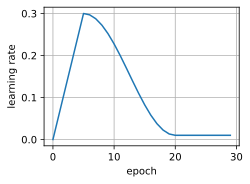

In [6]:
# Warmup과 Cosine Decay 시각화

num_epochs = 30

scheduler = CosineScheduler(
    max_updates=20,
    base_learning_rate=0.3,
    final_learning_rate=0.01,
    warmup_steps=5,
    warmup_begin_learning_rate=0.0,
)

learning_rates = [
    scheduler(epoch)
    for epoch in range(num_epochs)
]

d2l.plot(
    torch.arange(num_epochs),
    learning_rates,
    xlabel="epoch",
    ylabel="learning rate",
)

for epoch in range(6):
    print(
        f"Epoch {epoch}: "
        f"{learning_rates[epoch]:.4f}"
    )

print(
    "Epoch 20:",
    learning_rates[20],
)

train loss 0.176, train acc 0.933, test acc 0.904


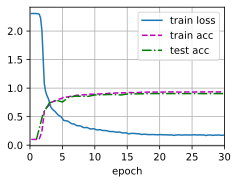

In [7]:
# Warmup과 Cosine Decay로 학습

num_epochs = 30

scheduler = CosineScheduler(
    max_updates=20,
    base_learning_rate=0.3,
    final_learning_rate=0.01,
    warmup_steps=5,
    warmup_begin_learning_rate=0.0,
)

model = create_lenet()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=scheduler(0),
)

train(
    model,
    train_iterator,
    test_iterator,
    num_epochs,
    loss_function,
    optimizer,
    device,
    scheduler,
)